In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from googleapiclient.discovery import build
from transformers import pipeline
from dotenv import load_dotenv
import os

In [11]:
load_dotenv()

API_KEY = os.getenv('YOUTUBE_API_KEY') 
SEARCH_QUERY = 'AI Bubble'
MAX_VIDEOS = 10
MAX_COMMENTS = 1000

In [12]:
# 1. Connect to YouTube
youtube = build('youtube', 'v3', developerKey=API_KEY)
print("Connected to YouTube API successfully.")

# 2. Load the Emotion Analysis model
# Categories: anger, disgust, fear, joy, neutral, sadness, surprise
print("Loading emotion analysis model (this might take a moment)...")
emotion_classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")
print("Model loaded successfully!")

Connected to YouTube API successfully.
Loading emotion analysis model (this might take a moment)...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 48115.58it/s]


Model loaded successfully!


In [13]:
def get_video_ids(query, max_results):
    """Searches YouTube and returns a list of video IDs."""
    request = youtube.search().list(
        part="id",
        q=query,
        type="video",
        order="viewCount",
        maxResults=max_results
    )
    response = request.execute()
    return [item['id']['videoId'] for item in response['items']]

def get_video_comments(video_id, max_results):
    """Fetches top comments from a specific video."""
    comments = []
    try:
        request = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=max_results,
            textFormat="plainText"
        )
        response = request.execute()
        
        for item in response['items']:
            comment = item['snippet']['topLevelComment']['snippet']['textDisplay']
            comments.append(comment)
    except Exception as e:
        print(f"Error fetching comments for video {video_id}: {e}")
        
    return comments

In [14]:
print(f"Searching for videos about: '{SEARCH_QUERY}'...")
video_ids = get_video_ids(SEARCH_QUERY, MAX_VIDEOS)

all_data = []

for video_id in video_ids:
    print(f"Fetching and analyzing comments for video ID: {video_id}...")
    comments = get_video_comments(video_id, MAX_COMMENTS)
    
    for comment in comments:
        # Truncate very long comments to avoid model token limits
        safe_comment = comment[:500] 
        
        # Analyze emotion
        result = emotion_classifier(safe_comment)[0]
        
        all_data.append({
            "Video_ID": video_id,
            "Comment": comment,
            "Emotion": result['label'],
            "Confidence": result['score']
        })

# Create a DataFrame
df = pd.DataFrame(all_data)
print("\nDone! Analyzed a total of", len(df), "comments.")

# Display the first few rows of our dataset
df.head()

Searching for videos about: 'AI Bubble'...
Fetching and analyzing comments for video ID: C6eXTvqdaro...
Fetching and analyzing comments for video ID: I5-ObZBfYAw...
Fetching and analyzing comments for video ID: Cn8HBj8QAbk...
Fetching and analyzing comments for video ID: Q0TpWitfxPk...
Fetching and analyzing comments for video ID: ah8KJ0u9I-A...
Fetching and analyzing comments for video ID: tAXKxKTGWFQ...
Fetching and analyzing comments for video ID: O8t50OxsfB8...
Fetching and analyzing comments for video ID: 5umJ63d3rzQ...
Fetching and analyzing comments for video ID: 0wxBHxpMFXA...
Fetching and analyzing comments for video ID: XSZQF1zjIXY...

Done! Analyzed a total of 1000 comments.


,Video_ID,Comment,Emotion,Confidence
0,C6eXTvqdaro,👉 Join The Waitlist: http://www.thewealthporta...,neutral,0.938735
1,C6eXTvqdaro,资金来源就是货币自主 货币超发,neutral,0.410197
2,C6eXTvqdaro,i hope its gonna crash got 10 k i have laying ...,sadness,0.898112
3,C6eXTvqdaro,I’ve heard some top critics saying it’s only n...,surprise,0.700971
4,C6eXTvqdaro,그리고 닷컴에서 살아남은 주식들은 지금의 메가코프.,neutral,0.563716


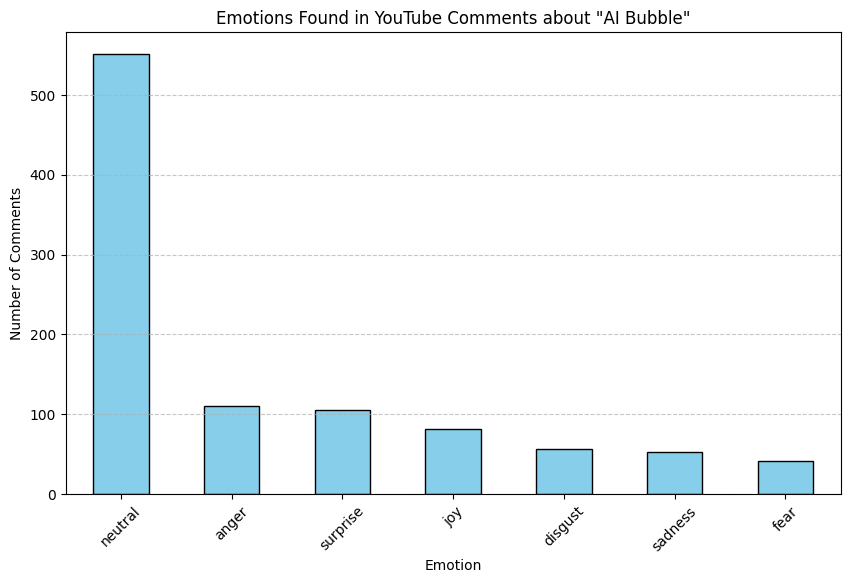

In [15]:
# Count the occurrences of each emotion
emotion_counts = df['Emotion'].value_counts()

# Create a bar chart
plt.figure(figsize=(10, 6))
emotion_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title(f'Emotions Found in YouTube Comments about "{SEARCH_QUERY}"')
plt.xlabel('Emotion')
plt.ylabel('Number of Comments')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()